In [1]:
!pip install transformers timm

In [2]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import copy
import shutil

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
def prepare_data(base_input_path, base_output_path, train_ratio=0.7, val_ratio=0.15):
    labels = [d for d in os.listdir(base_input_path)
              if os.path.isdir(os.path.join(base_input_path, d))]

    for label in labels:
        input_folder = os.path.join(base_input_path, label)
        images = os.listdir(input_folder)
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_dir = os.path.join(base_output_path, 'training', label)
        val_dir   = os.path.join(base_output_path, 'validation', label)
        test_dir  = os.path.join(base_output_path, 'testing', label)

        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir, exist_ok=True)
        os.makedirs(test_dir, exist_ok=True)

        for i, img_name in enumerate(images):
            src = os.path.join(input_folder, img_name)

            if i < n_train:
                dst = os.path.join(train_dir, img_name)
            elif i < n_train + n_val:
                dst = os.path.join(val_dir, img_name)
            else:
                dst = os.path.join(test_dir, img_name)

            if not os.path.exists(dst):
                shutil.copy(src, dst)

prepare_data(
    base_input_path="/kaggle/input/competitions/state-farm-distracted-driver-detection/imgs/train",
    base_output_path="/kaggle/working/master_data"
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [6]:
train_dataset = datasets.ImageFolder(
    "/kaggle/working/master_data/training", transform=train_transform)

val_dataset = datasets.ImageFolder(
    "/kaggle/working/master_data/validation", transform=val_transform)

test_dataset = datasets.ImageFolder(
    "/kaggle/working/master_data/testing", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=96, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=96, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=96, shuffle=False)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']


In [7]:
print("Total Training Images   :", len(train_dataset))
print("Total Validation Images :", len(val_dataset))
print("Total Test Images       :", len(test_dataset))

Total Training Images   : 15692
Total Validation Images : 3358
Total Test Images       : 3374


In [8]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    output_attentions=True
)

model.to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [9]:
total_layers = len(model.vit.encoder.layer)

for i, layer in enumerate(model.vit.encoder.layer):
    if i < total_layers // 2:
        for param in layer.parameters():
            param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [11]:
epochs = 3
best_val_acc = 0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(epochs):

    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs.logits, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-"*40)

torch.save(best_weights, "/kaggle/working/vit_best_model.pth")

Epoch 1
Train Loss: 0.4235, Train Acc: 0.8731
Val Loss: 0.0929, Val Acc: 0.9744
----------------------------------------
Epoch 2
Train Loss: 0.0648, Train Acc: 0.9809
Val Loss: 0.0534, Val Acc: 0.9842
----------------------------------------
Epoch 3
Train Loss: 0.0333, Train Acc: 0.9898
Val Loss: 0.0425, Val Acc: 0.9851
----------------------------------------


In [13]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    output_attentions=True
)

model.load_state_dict(torch.load("/kaggle/working/vit_best_model.pth",
                                 map_location=device))

model.to(device)
model.eval()

print("Saved weights loaded successfully!")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Saved weights loaded successfully!


In [14]:
test_loss, correct, total = 0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs.logits, labels)

        test_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_acc = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0359
Test Accuracy: 0.9920


In [15]:
def attention_rollout(attentions):
    result = torch.eye(attentions[0].size(-1)).to(device)

    for attention in attentions:
        attn = attention.mean(dim=1)
        attn += torch.eye(attn.size(-1)).to(device)
        attn /= attn.sum(dim=-1, keepdim=True)
        result = torch.matmul(attn, result)

    return result

In [16]:
def test_image(image_path):

    image = Image.open(image_path).convert("RGB")
    input_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        attentions = outputs.attentions

    probs = F.softmax(outputs.logits, dim=1)
    confidence, pred_class = torch.max(probs, dim=1)

    class_name = train_dataset.classes[pred_class.item()]
    print(f"Prediction: {class_name}")
    print(f"Confidence: {confidence.item()*100:.2f}%")

    rollout = attention_rollout(attentions)
    mask = rollout[0,0,1:].reshape(14,14).cpu().numpy()
    mask = cv2.resize(mask, (224,224))
    mask = (mask - mask.min())/(mask.max()-mask.min())

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="jet")
    plt.title("Attention Map")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(image)
    plt.imshow(mask, cmap="jet", alpha=0.5)
    plt.title("Overlay (XAI)")
    plt.axis("off")

    plt.show()

Prediction: c8
Confidence: 99.94%


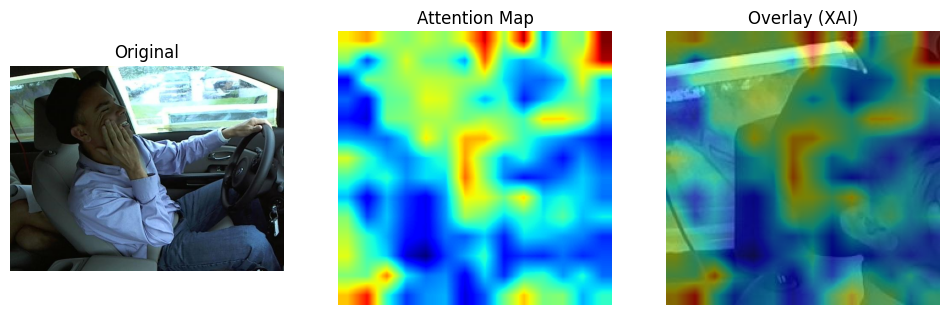

In [32]:
image_path = "/kaggle/working/master_data/testing/c8/img_13387.jpg"
test_image(image_path)